In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Wczytywanie danych i wyświetlanie przykładowych rekordów

In [2]:
df = pd.read_csv(os.path.join("../data", "domy.csv"))
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,?,Reg,Lvl,AllPub,...,0,?,?,?,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,?,Reg,Lvl,AllPub,...,0,?,?,?,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,?,IR1,Lvl,AllPub,...,0,?,?,?,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,?,IR1,Lvl,AllPub,...,0,?,?,?,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,?,IR1,Lvl,AllPub,...,0,?,?,?,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,?,IR1,Lvl,AllPub,...,0,?,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,?,Reg,Lvl,AllPub,...,0,?,?,?,0,8,2007,WD,Normal,307000
7,8,60,RL,?,10382,Pave,?,IR1,Lvl,AllPub,...,0,?,?,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,?,Reg,Lvl,AllPub,...,0,?,?,?,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,?,Reg,Lvl,AllPub,...,0,?,?,?,0,1,2008,WD,Normal,118000


# Wymiary datasetu (liczba rekordów x liczba cech)

In [3]:
df.shape

(1460, 81)

# Informacje o typach cech

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Id             1460 non-null   int64
 1   MSSubClass     1460 non-null   int64
 2   MSZoning       1460 non-null   str  
 3   LotFrontage    1460 non-null   str  
 4   LotArea        1460 non-null   int64
 5   Street         1460 non-null   str  
 6   Alley          1460 non-null   str  
 7   LotShape       1460 non-null   str  
 8   LandContour    1460 non-null   str  
 9   Utilities      1460 non-null   str  
 10  LotConfig      1460 non-null   str  
 11  LandSlope      1460 non-null   str  
 12  Neighborhood   1460 non-null   str  
 13  Condition1     1460 non-null   str  
 14  Condition2     1460 non-null   str  
 15  BldgType       1460 non-null   str  
 16  HouseStyle     1460 non-null   str  
 17  OverallQual    1460 non-null   int64
 18  OverallCond    1460 non-null   int64
 19  YearBuilt      14

# Analiza danych tekstowych

In [5]:
cat_cols = df.select_dtypes(include="str")
for cat in cat_cols:
    print(df[cat].value_counts())
    print()

MSZoning
RL           1151
RM            218
FV             65
RH             16
'C (all)'      10
Name: count, dtype: int64

LotFrontage
?        259
60.0     143
70.0      70
80.0      69
50.0      57
        ... 
138.0      1
160.0      1
152.0      1
153.0      1
46.0       1
Name: count, Length: 111, dtype: int64

Street
Pave    1454
Grvl       6
Name: count, dtype: int64

Alley
?       1369
Grvl      50
Pave      41
Name: count, dtype: int64

LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64

LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawye

### Z analizy danych tekstowych można wywnioskować, że do tych cech należą LotFrontage, MasVnrArea, GarageYrBlt, których wartości w większości przypadków można zapisać liczbowej (tak też wynika z dokumentacji). Przed dalszą analizą dokonane będzie przekształcenie tych cech do postaci numerycznej

In [6]:
df = df.copy()
df["LotFrontage"] = pd.to_numeric(df["LotFrontage"], errors="coerce")
df["MasVnrArea"] = pd.to_numeric(df["MasVnrArea"], errors="coerce")
df["GarageYrBlt"] = pd.to_numeric(df["GarageYrBlt"], errors="coerce")

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          1460 non-null   str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

# Analiza danych numerycznych

### Opis statystycznych danych numerycznych

In [8]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Analiza histogramów

array([[<Axes: title={'center': 'Id'}>,
        <Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>],
       [<Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>],
       [<Axes: title={'center': 'TotalBsmtSF'}>,
        <Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>],
       [<Axes: title={'center': 'BsmtHalfBath'}>,
        <Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,

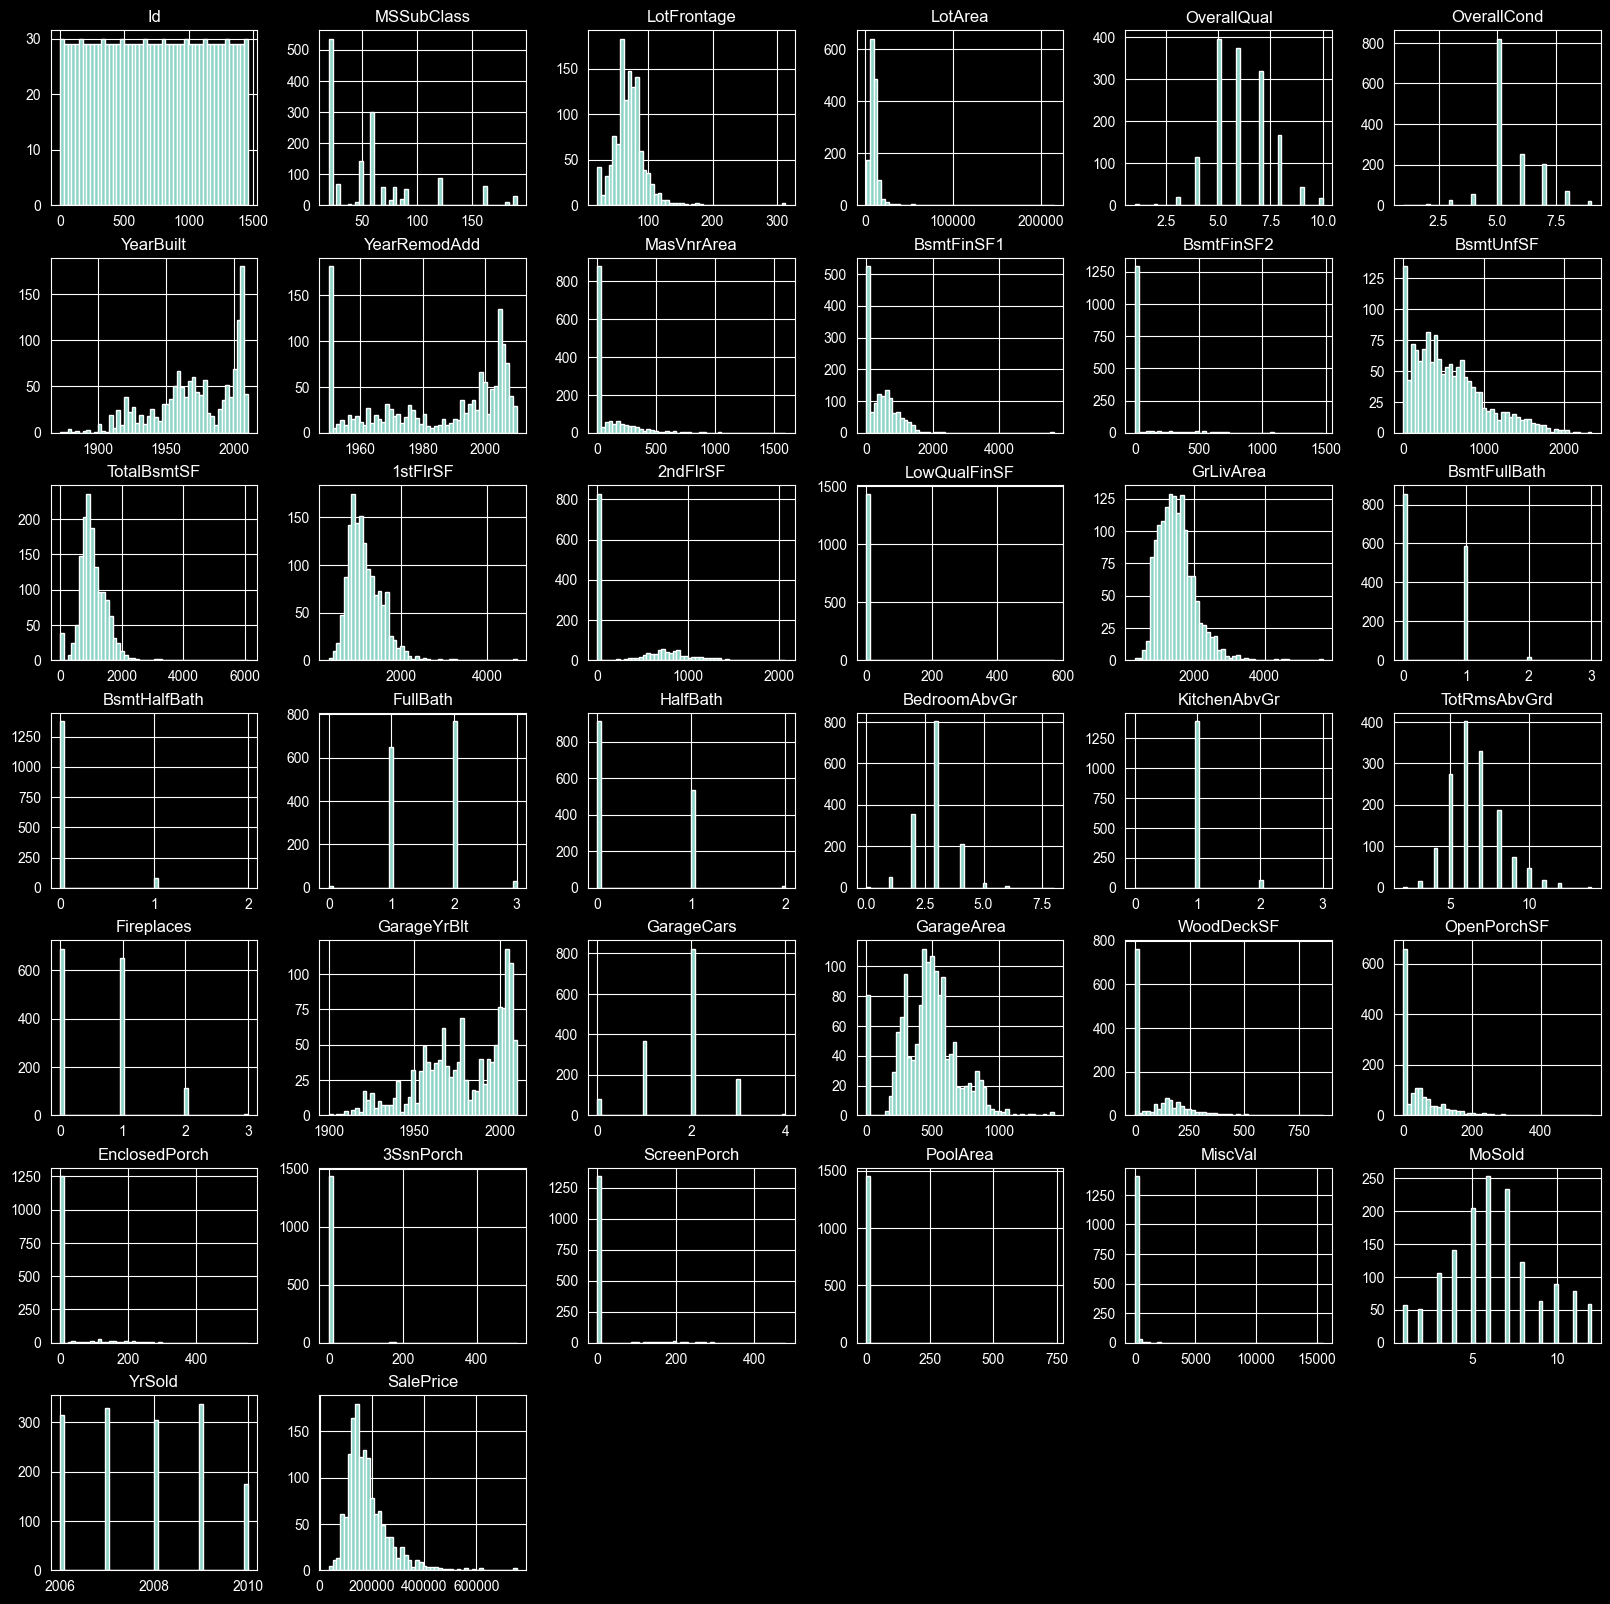

In [9]:
df.hist(figsize=(20,20), bins=50)

In [10]:
(df["LotFrontage"] > 200).sum()

np.int64(2)

In [11]:
(df["LotArea"] > 100000).sum()

np.int64(4)

In [12]:
(df["BsmtFinSF1"] > 4000).sum()

np.int64(1)

In [13]:
(df["BsmtFinSF2"] > 1000).sum()

np.int64(10)

In [14]:
df["Fireplaces"].value_counts()

Fireplaces
0    690
1    650
2    115
3      5
Name: count, dtype: int64

In [15]:
df["HalfBath"].value_counts()

HalfBath
0    913
1    535
2     12
Name: count, dtype: int64

In [16]:
df["GarageCars"].value_counts()

GarageCars
2    824
1    369
3    181
0     81
4      5
Name: count, dtype: int64

In [17]:
df["3SsnPorch"].value_counts()

3SsnPorch
0      1436
168       3
180       2
144       2
216       2
320       1
407       1
130       1
140       1
508       1
238       1
245       1
196       1
182       1
162       1
23        1
96        1
153       1
290       1
304       1
Name: count, dtype: int64

In [18]:
df["LowQualFinSF"].value_counts()

LowQualFinSF
0      1434
80        3
360       2
513       1
234       1
528       1
572       1
144       1
392       1
371       1
390       1
420       1
473       1
156       1
515       1
53        1
232       1
481       1
120       1
514       1
397       1
479       1
205       1
384       1
Name: count, dtype: int64

In [19]:
df["PoolArea"].value_counts()

PoolArea
0      1453
512       1
648       1
576       1
555       1
480       1
519       1
738       1
Name: count, dtype: int64

In [20]:
df["MiscVal"].value_counts()

MiscVal
0        1408
400        11
500         8
700         5
450         4
2000        4
600         4
480         2
1200        2
350         1
15500       1
800         1
3500        1
1300        1
54          1
620         1
560         1
1400        1
8300        1
1150        1
2500        1
Name: count, dtype: int64

### Usunięcie kilku kolumn

In [21]:
del_cols = ["Id", "Street", "Alley", "Utilities", "PoolQC", "PoolArea", "MiscVal", "LowQualFinSF", "3SsnPorch"]
df = df.copy().drop(del_cols, axis=1)

### Macierz korelacji

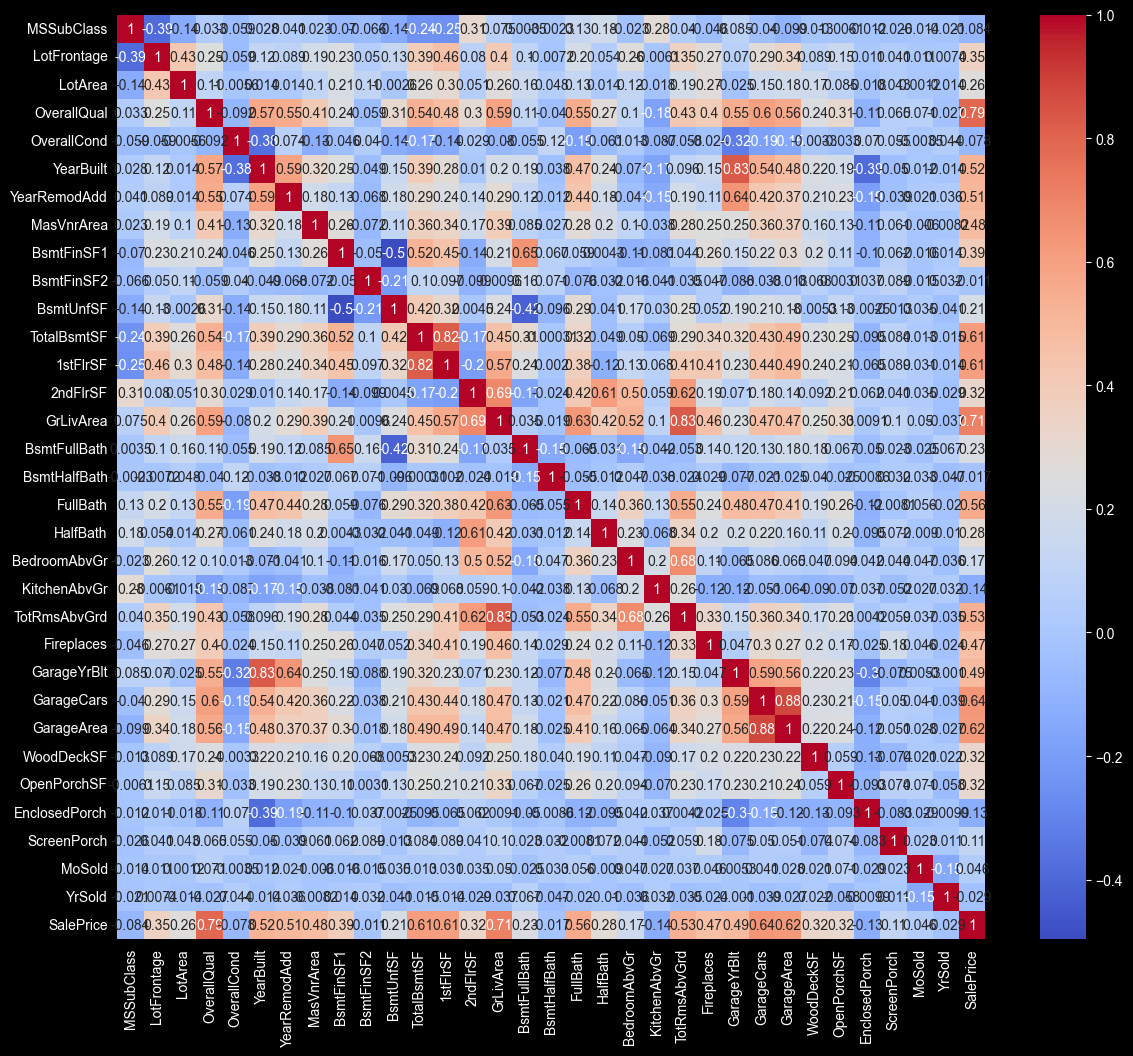

In [22]:
corr = df.select_dtypes(include="number").corr()
plt.figure(figsize=(14,12))
sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.show()

In [23]:
corr["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
MoSold           0.046432
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

# Dokładniejsza analiza MasVnrType, która nie jest wypełniona całkowicie

In [24]:
df["MasVnrType"].value_counts()

MasVnrType
BrkFace    445
Stone      128
BrkCmn      15
?            8
Name: count, dtype: int64

In [25]:
print(df["MasVnrType"].isna().sum())

864
